In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo

import atmo3 as a3

In [2]:
# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [2048, 2048, 1024]
box_length = [20000., 20000., 50000.]

boresight  = jnp.array([box_length[0]//2., box_length[1]//2.])
#freqs      = jnp.logspace(1, 3, num=1000)
freqs = jnp.linspace(1., 1000., num=1000)
passband   = {'nu': jnp.array([150.]), 'g(nu)': jnp.array([1.])}
fwhm       = 10.

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 9, 16, 0, 0, tzinfo=timezone.utc)

In [3]:
atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for September 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

In [4]:
# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

In [5]:
atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)

1.1099999999999999 0.0607453701939497


In [6]:
ds = atmo_box.grid_wsp.grid_spacing[2] * jnp.ones((nside_grid[2],))

In [7]:
rho_w = atmo_box.atm_calibrator.q2rho_h2o*atmo_box.atm_calibrator.spec_humidity_profile
T = atmo_box.atm_calibrator.temperature_profile
P = atmo_box.atm_calibrator.pressure

In [8]:
rho_w.shape

(1024,)

In [9]:
gamma_wet = []
gamma_dry = []

for j in range(nside_grid[2]):
    gamma_d, gamma_w = a3.compute_attenuation_point(atmo_box.atm_calibrator.temperature_profile[j], atmo_box.atm_calibrator.pressure[j], rho_w[j], freqs)
    gamma_wet.append(gamma_w)
    gamma_dry.append(gamma_d)
    
gamma_wet = jnp.array(gamma_wet).T 
gamma_dry = jnp.array(gamma_dry).T

In [10]:
print(gamma_wet)

[[ 2.70164631e-06  2.62514303e-06  2.52628894e-06 ... -4.53544130e-16
  -4.44997810e-16 -4.35493773e-16]
 [ 1.08509839e-05  1.05436917e-05  1.01466524e-05 ... -1.80989746e-15
  -1.77542078e-15 -1.73710380e-15]
 [ 2.45856962e-05  2.38893642e-05  2.29897766e-05 ... -4.05577732e-15
  -3.97708190e-15 -3.88970945e-15]
 ...
 [ 5.41789025e+01  5.27469325e+01  5.08676349e+01 ... -7.91547898e-08
  -8.06948977e-08 -8.21813103e-08]
 [ 4.60937493e+01  4.48715653e+01  4.32688362e+01 ... -6.59071686e-08
  -6.71832923e-08 -6.84145035e-08]
 [ 3.98713290e+01  3.88111818e+01  3.74218318e+01 ... -5.57975460e-08
  -5.68721719e-08 -5.79085860e-08]]


In [11]:
transmission_h2o = a3.attenuation_to_transmission(gamma_wet, ds)
transmission_o2  = a3.attenuation_to_transmission(gamma_dry,  ds)
transmission_tot = a3.attenuation_to_transmission(gamma_dry+gamma_wet,  ds)

Text(0.5, 1.0, 'Atmospheric transmission, Atacama, 2023-09-16 00:00:00+00:00')

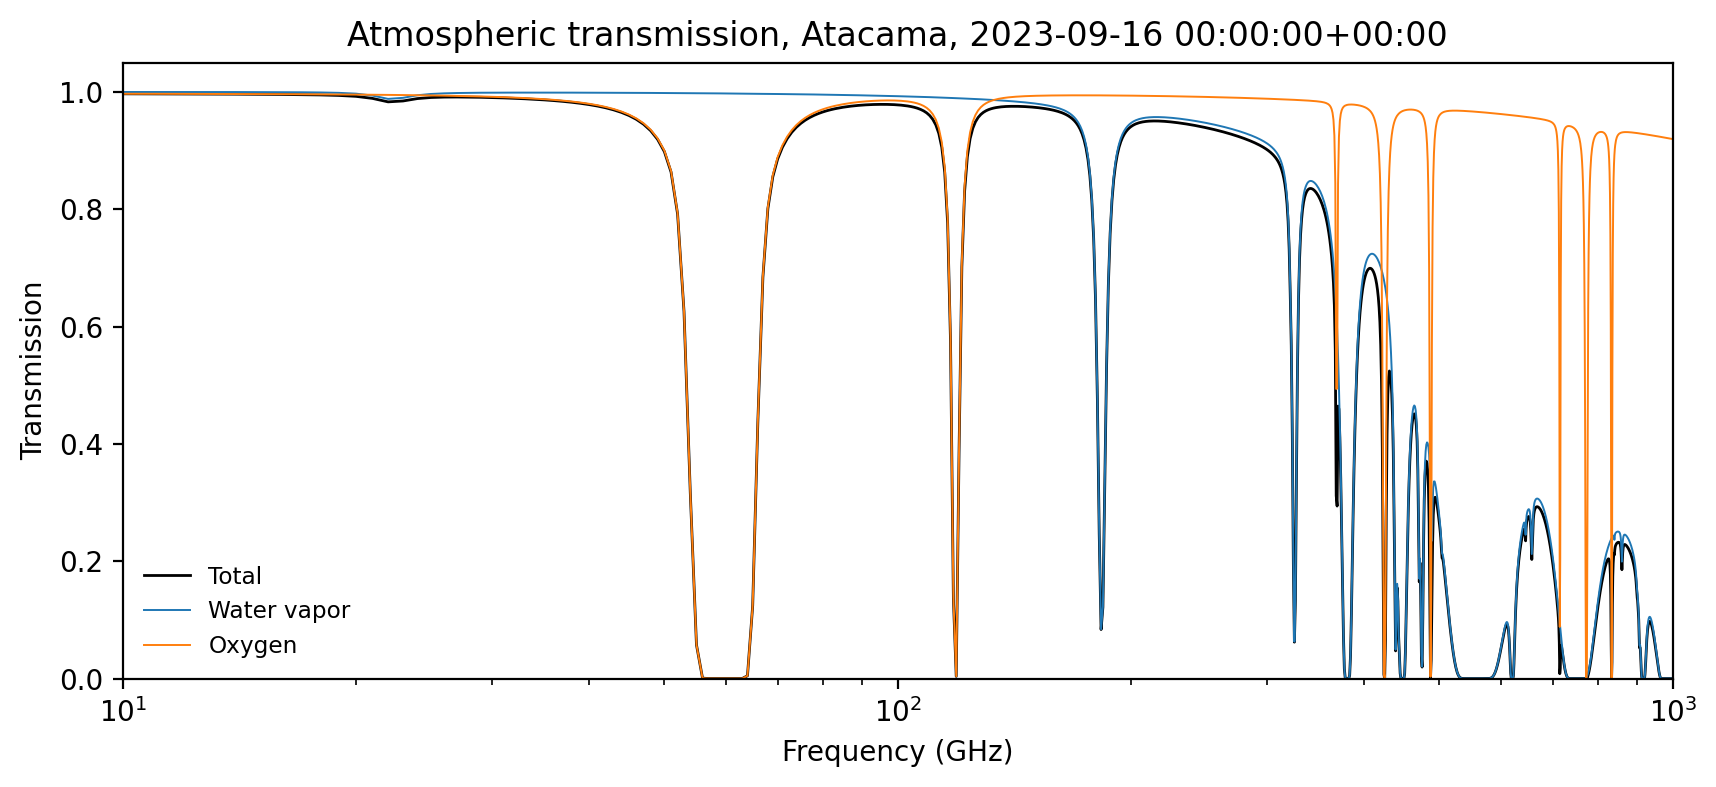

In [12]:
plt.figure(figsize=(10,4),dpi=200)
plt.semilogx(freqs, transmission_tot, 'k-', lw=1.0, label='Total')
plt.semilogx(freqs, transmission_h2o, '-', lw=0.7, label='Water vapor')
plt.semilogx(freqs, transmission_o2,  '-', lw=0.7, label='Oxygen')
plt.ylim(ymin=0., ymax=1.05)
plt.xlim(xmin=10, xmax=1000)
plt.legend(fontsize='small', frameon=False)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission')
plt.title(f'Atmospheric transmission, Atacama, {time_utc}')

In [13]:

vmap_attenuation = jax.vmap(a3.compute_attenuation_water_vapor_am, in_axes=(0, 0, 0, None), out_axes=1)

# 2. Feed the full 1D profile arrays directly into the new function
# No for-loops required!
gamma_wet_array = vmap_attenuation(
    atmo_box.atm_calibrator.temperature_profile,
    atmo_box.atm_calibrator.pressure,
    rho_w,
    freqs
)

transmission_h2o_am = a3.attenuation_to_transmission(gamma_wet_array, ds)


In [14]:
print(gamma_wet)

[[ 2.70164631e-06  2.62514303e-06  2.52628894e-06 ... -4.53544130e-16
  -4.44997810e-16 -4.35493773e-16]
 [ 1.08509839e-05  1.05436917e-05  1.01466524e-05 ... -1.80989746e-15
  -1.77542078e-15 -1.73710380e-15]
 [ 2.45856962e-05  2.38893642e-05  2.29897766e-05 ... -4.05577732e-15
  -3.97708190e-15 -3.88970945e-15]
 ...
 [ 5.41789025e+01  5.27469325e+01  5.08676349e+01 ... -7.91547898e-08
  -8.06948977e-08 -8.21813103e-08]
 [ 4.60937493e+01  4.48715653e+01  4.32688362e+01 ... -6.59071686e-08
  -6.71832923e-08 -6.84145035e-08]
 [ 3.98713290e+01  3.88111818e+01  3.74218318e+01 ... -5.57975460e-08
  -5.68721719e-08 -5.79085860e-08]]


Text(0.5, 1.0, 'Atmospheric transmission, Atacama, 2023-09-16 00:00:00+00:00')

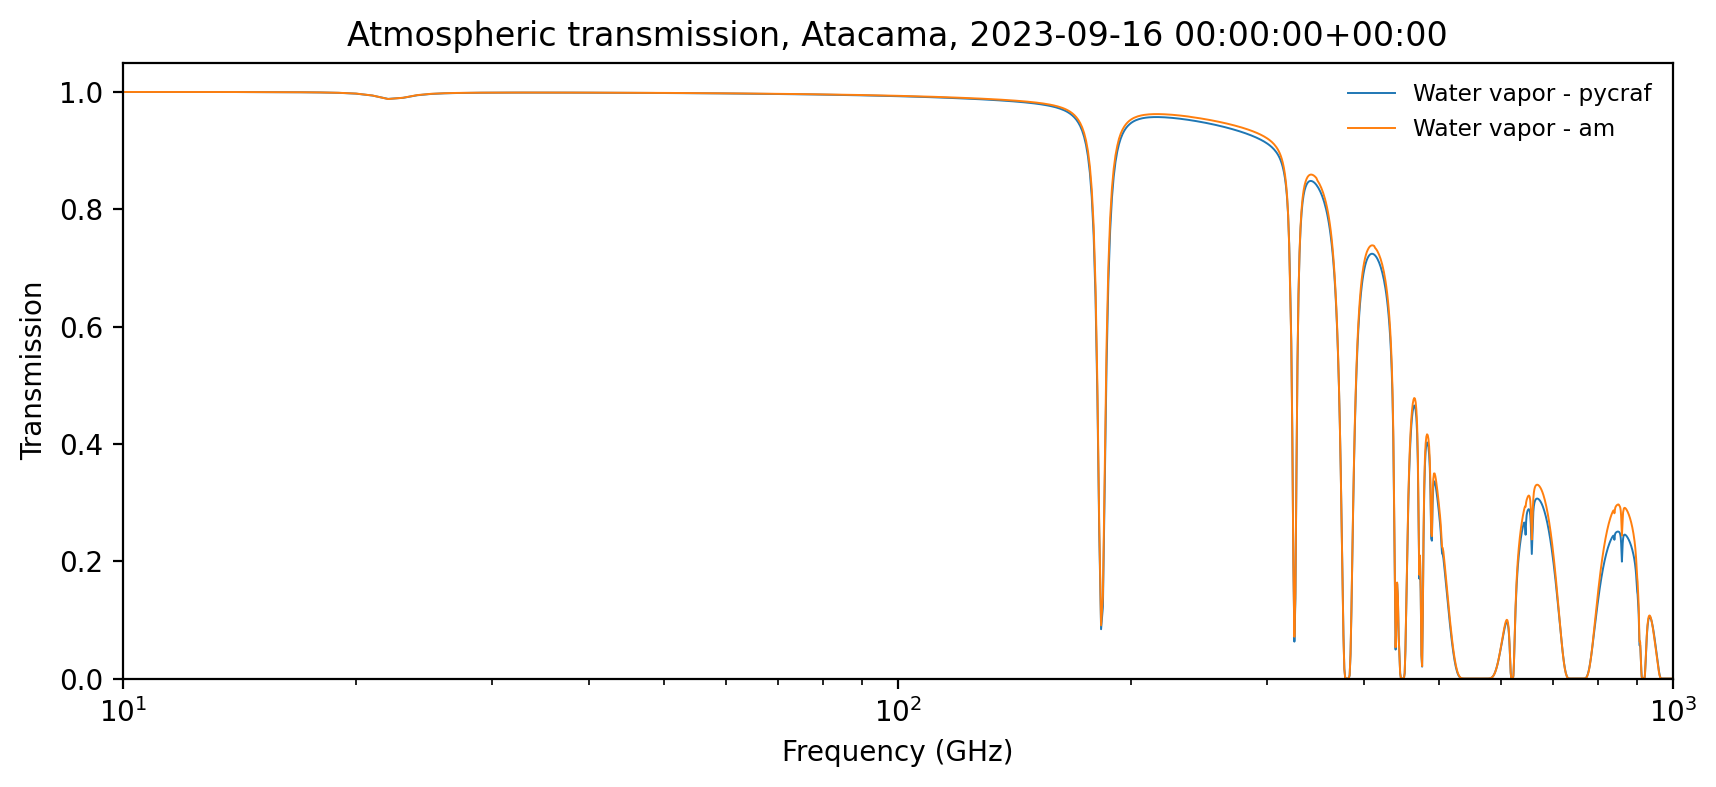

In [15]:
plt.figure(figsize=(10,4),dpi=200)

plt.semilogx(freqs, transmission_h2o, '-', lw=0.7, label='Water vapor - pycraf')
plt.semilogx(freqs, transmission_h2o_am, '-', lw=0.7, label='Water vapor - am')
plt.ylim(ymin=0., ymax=1.05)
plt.xlim(xmin=10, xmax=1000)
plt.legend(fontsize='small', frameon=False)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission')
plt.title(f'Atmospheric transmission, Atacama, {time_utc}')

In [16]:
vmap_attenuation_dry = jax.vmap(a3.compute_attenuation_dry_air_am, in_axes=(0, 0,0,  None), out_axes=1)
gamma_dry_array = vmap_attenuation_dry(
    atmo_box.atm_calibrator.temperature_profile,
    atmo_box.atm_calibrator.pressure,
    rho_w,
    freqs
)

transmission_o2_am = a3.attenuation_to_transmission(gamma_dry_array, ds)

Text(0.5, 1.0, 'Atmospheric transmission, Atacama, 2023-09-16 00:00:00+00:00')

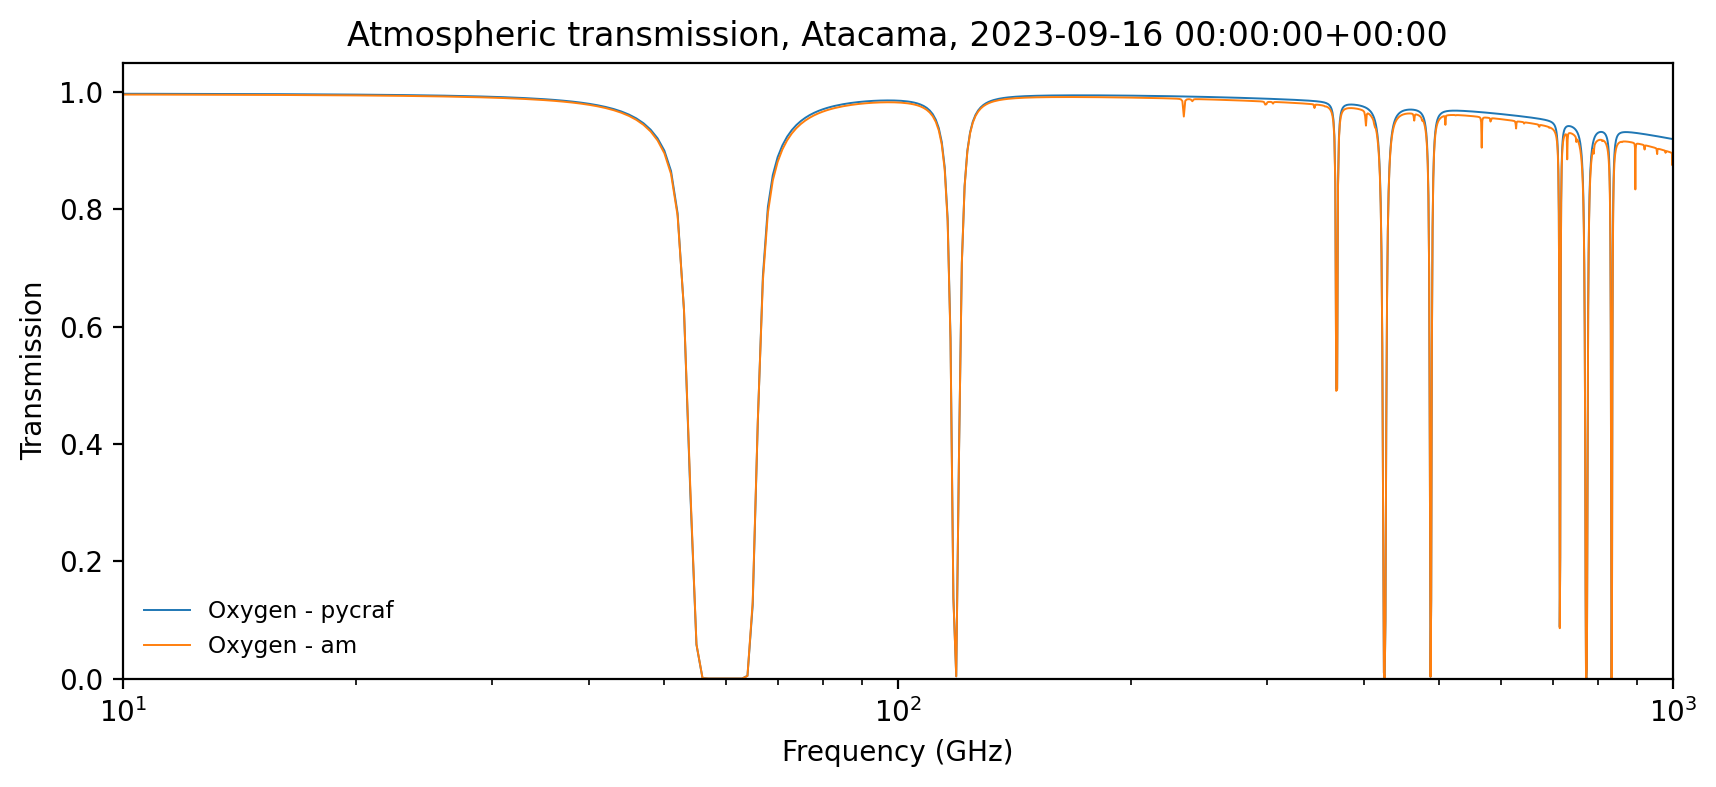

In [17]:
plt.figure(figsize=(10,4),dpi=200)
plt.semilogx(freqs, transmission_o2,  '-', lw=0.7, label='Oxygen - pycraf')
plt.semilogx(freqs, transmission_o2_am,  '-', lw=0.7, label='Oxygen - am')
plt.ylim(ymin=0., ymax=1.05)
plt.xlim(xmin=10, xmax=1000)
plt.legend(fontsize='small', frameon=False)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission')
plt.title(f'Atmospheric transmission, Atacama, {time_utc}')

Text(0.5, 1.0, 'Atmospheric transmission, Atacama, 2023-09-16 00:00:00+00:00')

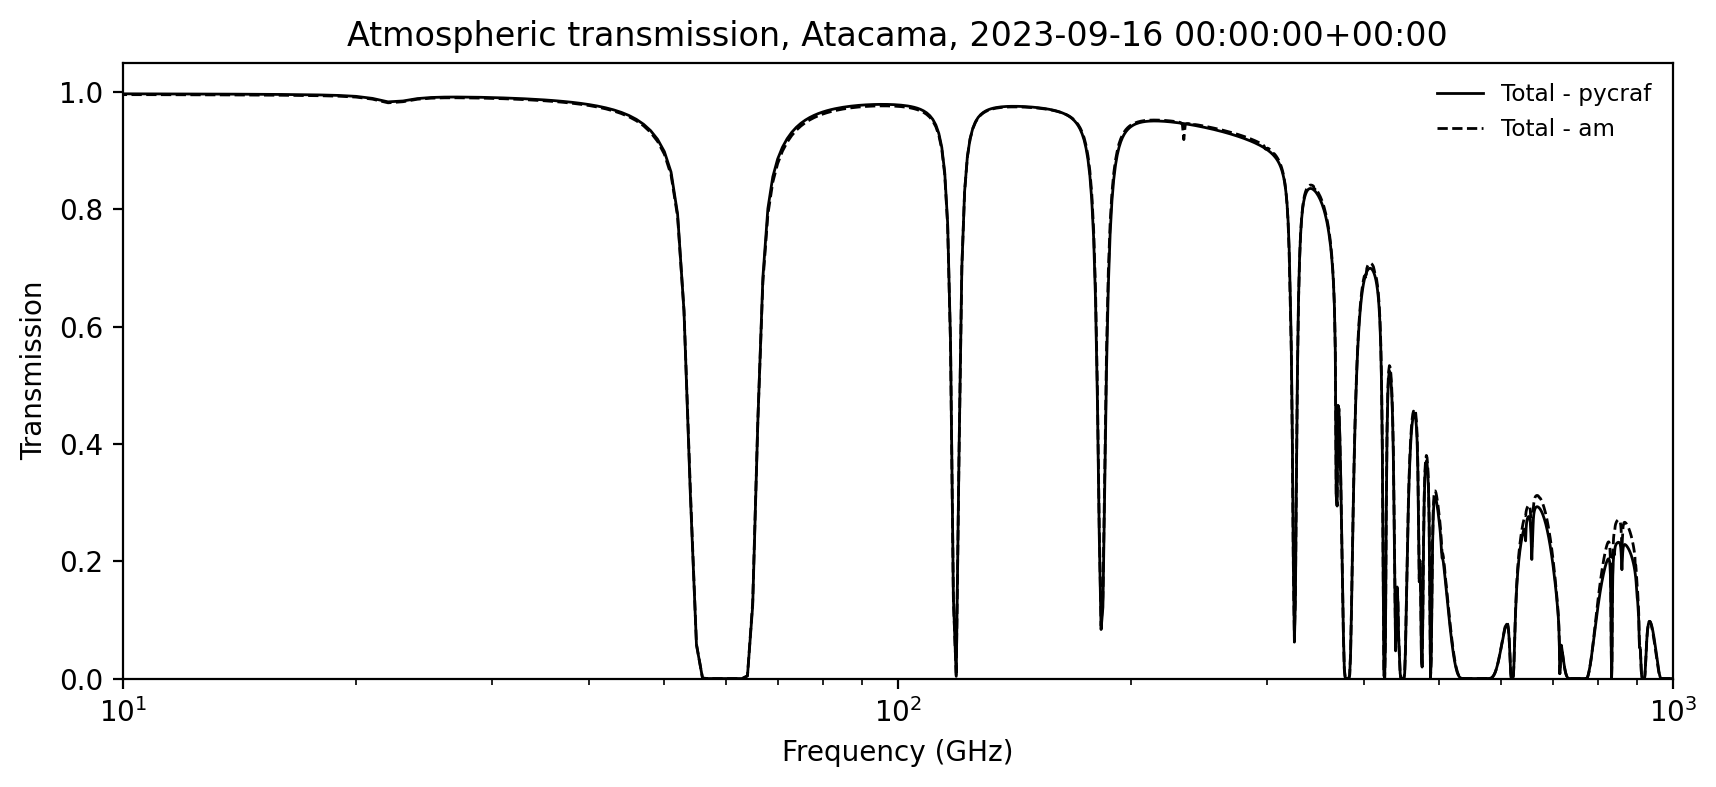

In [18]:
gamma_total_am = gamma_wet_array + gamma_dry_array
transmission_total_am = a3.attenuation_to_transmission(gamma_total_am, ds)
plt.figure(figsize=(10,4),dpi=200)
plt.semilogx(freqs, transmission_tot, 'k-', lw=1.0, label='Total - pycraf')
plt.semilogx(freqs, transmission_total_am, 'k--', lw=1.0, label='Total - am')
plt.ylim(ymin=0., ymax=1.05)
plt.xlim(xmin=10, xmax  =1000)
plt.legend(fontsize='small', frameon=False)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission')
plt.title(f'Atmospheric transmission, Atacama, {time_utc}') 


Text(0.5, 1.0, 'Percentage difference between AM and pycraf, Atacama, 2023-09-16 00:00:00+00:00')

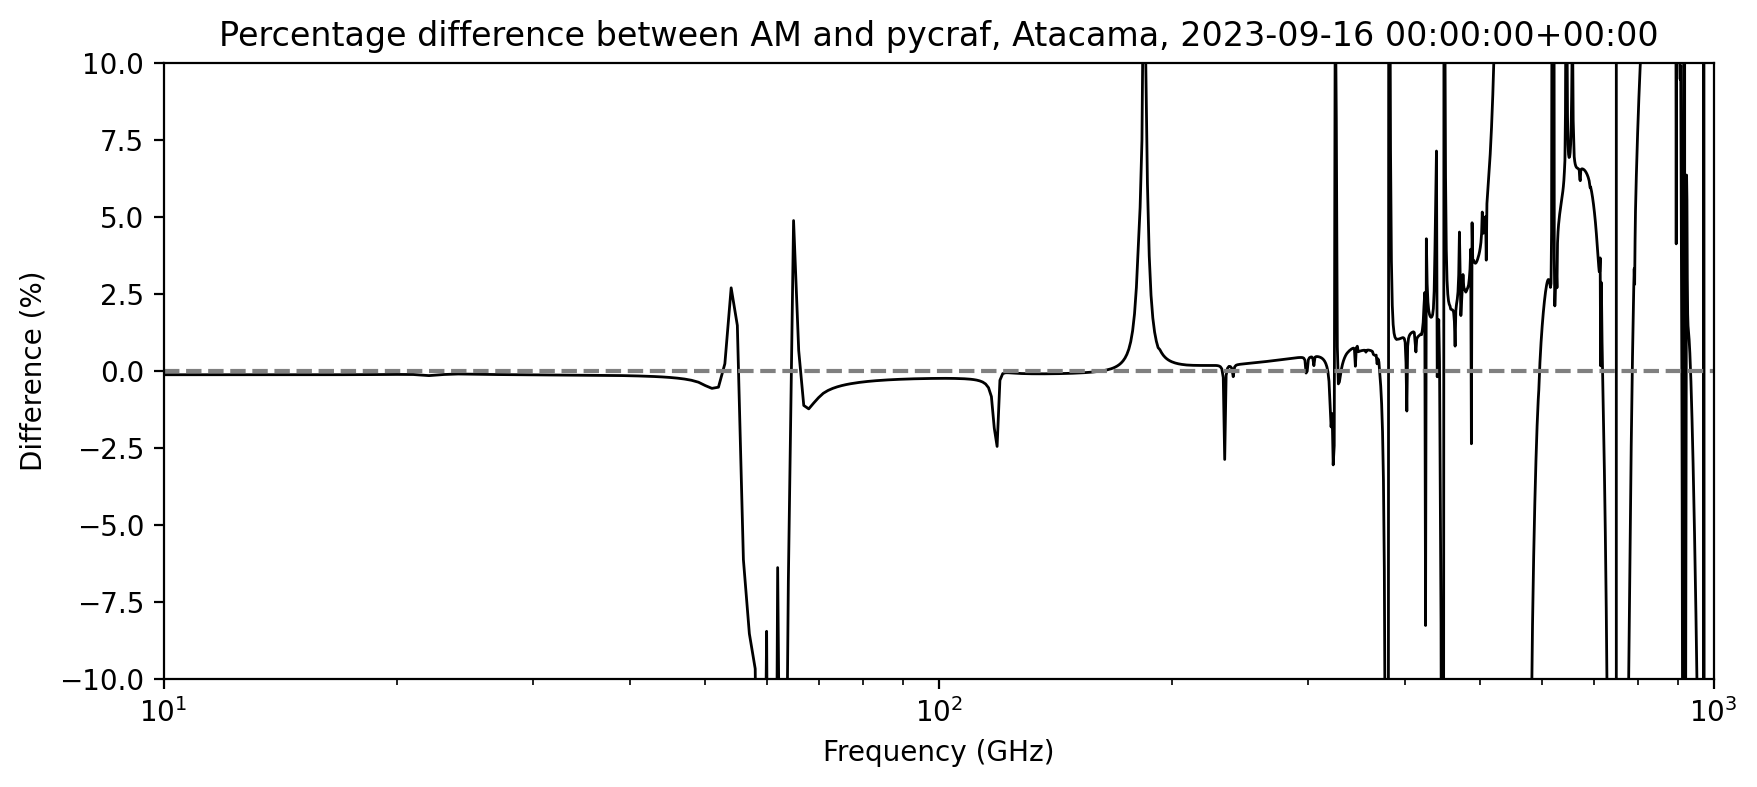

In [19]:
#Let's plot the total difference between the two methods as a percentage of the pycraf value
plt.figure(figsize=(10,4),dpi=200)
plt.semilogx(freqs, 100*(transmission_total_am - transmission_tot)/transmission_tot, 'k-', lw=1.0)
plt.axhline(0, color='gray', ls='--')
plt.ylim(ymin=-10., ymax=10.)
plt.xlim(xmin=10, xmax=1000)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Difference (%)')
plt.title(f'Percentage difference between AM and pycraf, Atacama, {time_utc}')

In [20]:
from scipy import constants

# Let's have the o3 now
o3file = f'{atmo3_data}era5/2023/o3.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
o3_profile_1d = atmo_box.super_grid.era5_interp2site(o3file)


# --- 2. Define Physical Constants ---
M_air = 28.9647e-3 # Molar mass of dry air in kg/mol
M_o3 = 47.9982e-3  # Molar mass of Ozone (O3) in kg/mol

# --- 3. Calculate Number Density (molecules / m^3) ---
# Calculate total number density of air molecules
n_air = P / (constants.k * T)

# Convert ozone mass mixing ratio to volume mixing ratio
vmr_o3 = o3_profile_1d * (M_air / M_o3)

# Calculate final ozone number density
P_o3 = vmr_o3 * P # Partial pressure of ozone in Pa


In [21]:
vmap_attenuation_o3 = jax.vmap(a3.compute_attenuation_ozone_am, in_axes=(0, 0,0,0, None), out_axes=1)
gamma_o3_array = vmap_attenuation_o3(
    atmo_box.atm_calibrator.temperature_profile,
    atmo_box.atm_calibrator.pressure,
    P_o3,
    rho_w,
    freqs,
)

transmission_o3_am = a3.attenuation_to_transmission(gamma_o3_array, ds)

In [22]:
Total_attenuation_am = gamma_wet_array + gamma_dry_array + gamma_o3_array
transmission_total_am_with_o3 = a3.attenuation_to_transmission(Total_attenuation_am     , ds)

Text(0.5, 1.0, 'Atmospheric transmission, Atacama, 2023-09-16 00:00:00+00:00')

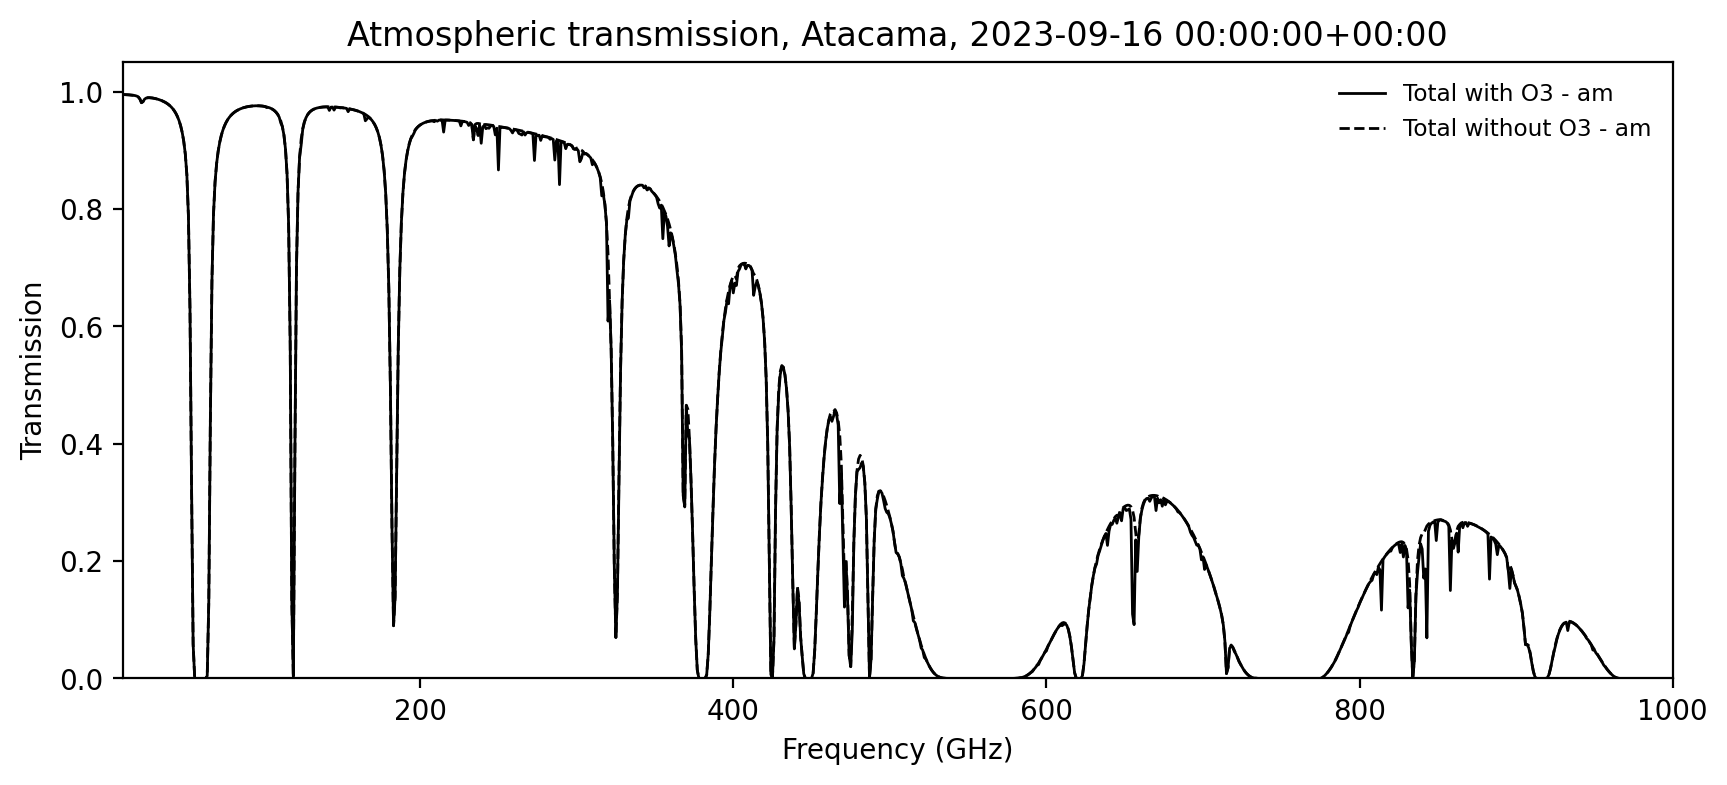

In [23]:
plt.figure(figsize=(10,4),dpi=200)
plt.plot(freqs, transmission_total_am_with_o3, 'k-', lw=1.0, label='Total with O3 - am')
plt.plot(freqs, transmission_total_am, 'k--', lw=1.0, label='Total without O3 - am')
plt.ylim(ymin=0., ymax=1.05)
plt.xlim(xmin=10, xmax=1000)
plt.legend(fontsize='small', frameon=False)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission')
plt.title(f'Atmospheric transmission, Atacama, {time_utc}')